In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rajlakshmi2028/datascience-job-dataset/data_science_job.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/kaggle/input/datasets/rajlakshmi2028/datascience-job-dataset/data_science_job.csv')

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
10780,6706,city_21,0.624,NaN,No relevent experience,no_enrollment,Graduate,Other,0.0,NaN,NaN,154.0,1.0
18345,32071,city_16,0.910,Male,No relevent experience,Full time course,Graduate,STEM,4.0,50-99,Pvt Ltd,9.0,1.0
8476,11067,city_103,0.920,Male,Has relevent experience,Full time course,Graduate,STEM,7.0,5000-9999,Public Sector,68.0,1.0
1973,16130,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,Other,5.0,10000+,NaN,NaN,0.0
3068,31140,city_16,0.910,Male,No relevent experience,no_enrollment,Primary School,NaN,0.0,NaN,NaN,31.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [10]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

### Finding cols has less than 5% missing Values

In [13]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]

In [14]:
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [17]:
new_df=df[cols].dropna()

In [18]:
df.shape

(19158, 13)

In [19]:
new_df.shape

(17182, 5)

In [23]:
len(df[cols].dropna())/len(df)

0.8968577095730244

### Checking Distribution of the data after Dropna

<Axes: xlabel='city_development_index', ylabel='Count'>

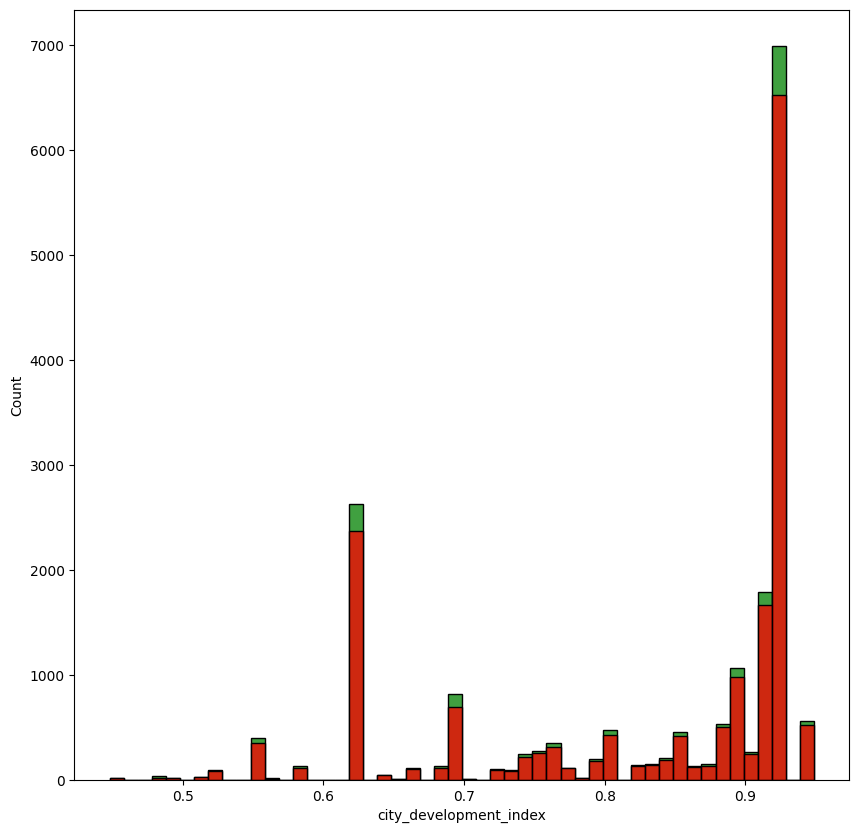

In [29]:
plt.figure(figsize=(10,10))
plt.subplot(1,1,1)

sns.histplot(df['city_development_index'],bins=50,color='Green')

sns.histplot(new_df['city_development_index'],bins=50,color='red')

<Axes: xlabel='city_development_index', ylabel='Density'>

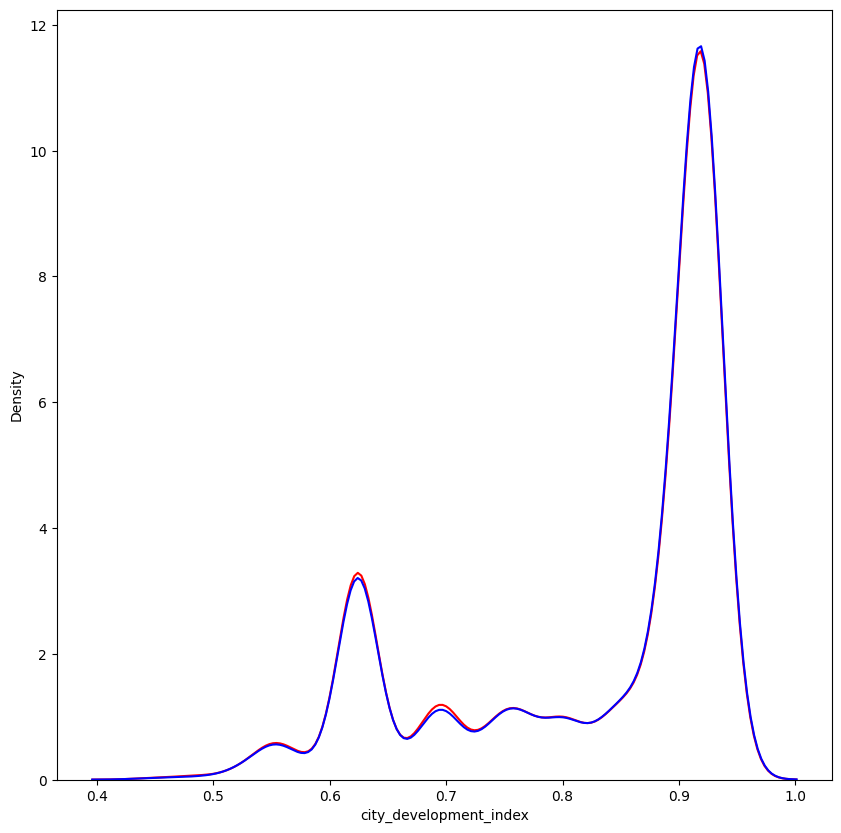

In [34]:
plt.figure(figsize=(10,10))
plt.subplot(111)

sns.kdeplot(df['city_development_index'],color='red')

sns.kdeplot(new_df['city_development_index'],color='blue')

<Axes: xlabel='training_hours', ylabel='Count'>

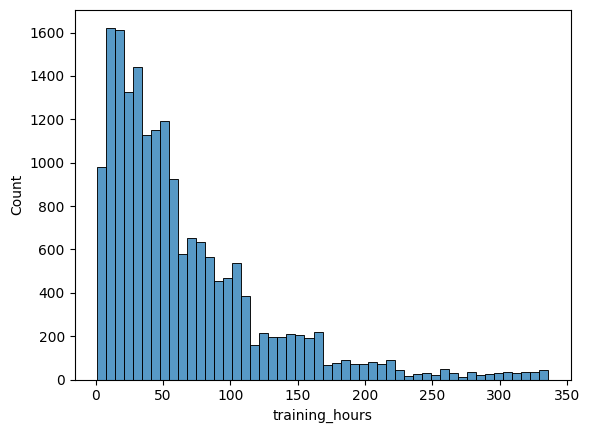

In [40]:
sns.histplot(df['training_hours'],bins=50)

<Axes: >

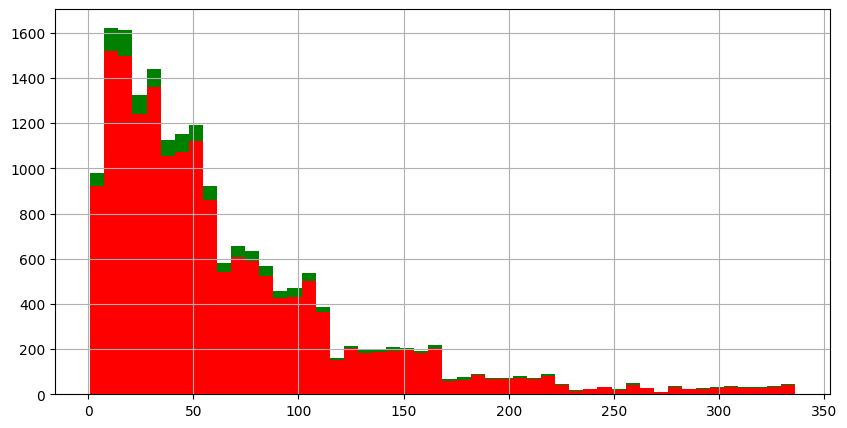

In [42]:
plt.figure(figsize=(10,5))
plt.subplot(111)

df['training_hours'].hist(bins=50,color='Green')

new_df['training_hours'].hist(bins=50,color='red')

In [56]:
temp=pd.concat([
    df['education_level'].value_counts()/len(df),

    new_df['education_level'].value_counts()/len(df)
],axis=1)

temp.columns=['original','cca']

In [57]:
temp

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876


In [58]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [60]:
df[['experience','target']].corr()

,experience,target
experience,1.000000,-0.178238
target,-0.178238,1.000000


In [63]:
pd.crosstab(df['education_level'], df['target'])

target,0.0,1.0
education_level,,
Graduate,8353,3245
High School,1623,394
Masters,3426,935
Phd,356,58
Primary School,267,41


<Axes: xlabel='education_level'>

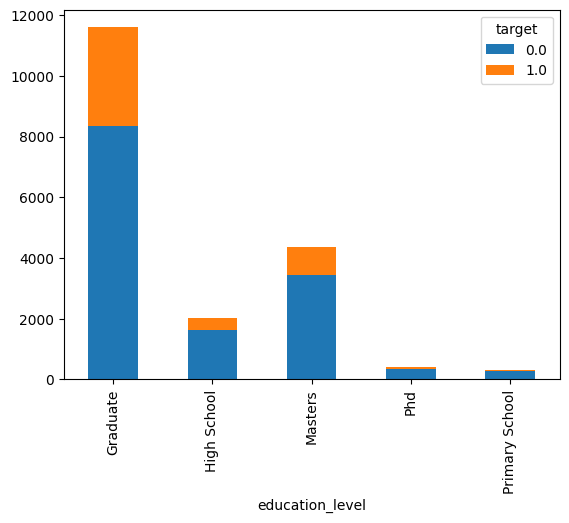

In [64]:
pd.crosstab(df['education_level'], df['target']).plot(kind='bar', stacked=True)